いい感じだった手法の効果を確認する．実際に等級判別してみて判断

In [ ]:
import os 
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import scipy.stats as stats
import seaborn as sns
import pandas as pd
from sklearn.metrics import roc_curve
import re
import math
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score, recall_score, f1_score
import joblib
import time
from ultralytics import YOLO

In [ ]:
# run_process.ipynb のセル

# 1. pip install したライブラリをインポート
import maesyori_fast

# 2. パラメータを定義
BASE_DIR = '/home/data/1201_humomentstest' 
MODEL_PATH = '/home/YOLO/0708_maesyori/datasets/train/weights/best.pt'
AREA_THRESHOLD = 50000
TARGET_FOLDERS = ['A', 'B', 'C'] 

# 3. 実行
# (if __name__ == "__main__": は引き続き必要)
if __name__ == "__main__":
    start = time.time()
    maesyori_fast.run(
        base_dir=BASE_DIR,
        model_path=MODEL_PATH,
        target_folders=TARGET_FOLDERS,
        area_threshold=AREA_THRESHOLD,
        max_workers=2
    )
current_time = time.time()
print(f"--- [1. 前処理] 完了 (所要時間: {current_time - start:.2f}秒) ---")

In [ ]:

import hida_fast
import keijo_fast
import size_module_fast
#判別フェーズ
#特徴量抽出
data = "1201_humomentstest"
hida_tappleA = hida_fast.Hida_folder_jikuari_img_xxxx(base_dir=f"/home/data/{data}",subfolder="A",method="45rotate",n=9,T=0.4)
result_hidaA = hida_tappleA.run_all()
hida_tappleB = hida_fast.Hida_folder_jikuari_img_xxxx(base_dir=f"/home/data/{data}",subfolder="B",method="45rotate",n=9,T=0.4)
result_hidaB = hida_tappleB.run_all()
hida_tappleC = hida_fast.Hida_folder_jikuari_img_xxxx(base_dir=f"/home/data/{data}",subfolder="C",method="45rotate",n=9,T=0.4)
result_hidaC = hida_tappleC.run_all()
dfA = pd.DataFrame(result_hidaA, columns=["filename", "R"])
dfB = pd.DataFrame(result_hidaB, columns=["filename", "R"])
dfC = pd.DataFrame(result_hidaC, columns=["filename", "R"])
dfA ["Label"] = "0"
dfB ["Label"] = "1"
dfC ["Label"] = "2"
result_hida = pd.concat([dfA, dfB, dfC], axis=0,ignore_index=True)
hida_time = time.time() - start
print(f"Hida_fastの総処理時間: {hida_time:.2f}秒")
size_tappleA = size_module_fast.Size_folder_taikakusen(base_dir=f"/home/data/{data}",subfolder="A")
result_sizeA = size_tappleA.run()
size_tappleB = size_module_fast.Size_folder_taikakusen(base_dir=f"/home/data/{data}",subfolder="B")
result_sizeB = size_tappleB.run()
size_tappleC = size_module_fast.Size_folder_taikakusen(base_dir=f"/home/data/{data}",subfolder="C")
result_sizeC = size_tappleC.run()
dfA = pd.DataFrame(result_sizeA, columns=["filename", "size_count"])                                                    
dfB = pd.DataFrame(result_sizeB, columns=["filename", "size_count"])
dfC = pd.DataFrame(result_sizeC, columns=["filename", "size_count"])
result_size = pd.concat([dfA, dfB, dfC], axis=0,ignore_index=True)
size_time = time.time() - start
print(f"Size_module_fastの総処理時間: {size_time:.2f}秒")
keijo_tappleA = keijo_fast.Keijo_folder(base_dir=f"/home/data/{data}",subfolder="A")
result_keijoA = keijo_tappleA.run()
keijo_tappleB = keijo_fast.Keijo_folder(base_dir=f"/home/data/{data}",subfolder="B")
result_keijoB = keijo_tappleB.run()
keijo_tappleC = keijo_fast.Keijo_folder(base_dir=f"/home/data/{data}",subfolder="C")
result_keijoC = keijo_tappleC.run()
dfA = pd.DataFrame(result_keijoA, columns=["filename", "MSE"])
dfB = pd.DataFrame(result_keijoB, columns=["filename", "MSE"])
dfC = pd.DataFrame(result_keijoC, columns=["filename", "MSE"])
result_keijo = pd.concat([dfA, dfB, dfC], axis=0,ignore_index=True)
keijo_time = time.time() - start
print(f"Keijo_fastの総処理時間: {keijo_time:.2f}秒")
df_merged = pd.merge(result_keijo, result_size, on="filename")
df_merged = pd.merge(df_merged, result_hida, on="filename")
df_merged.to_csv(f"/home/data/{data}/feature.csv", index=False)

✅ データ読み込み成功: /home/data/1201_humomentstest/feature.csv

--- クラス分布 ---
Train Data Class Distribution:
Label
0    347
1    211
2    168
Name: count, dtype: int64

Test Data Class Distribution:
Label
0    149
1     91
2     72
Name: count, dtype: int64

--- 4. K-Fold交差検証とハイパーパラメータチューニング ---

--- 5分割交差検証 (K-Fold) の全平均スコア ---
評価指標: f1_macro
処理時間: 0.94秒
 param_svm__C param_svm__gamma  mean_test_score  std_test_score
         10.0            scale         0.623232        0.030797
         10.0             auto         0.623232        0.030797
         10.0              0.1         0.616476        0.046964
          1.0            scale         0.614066        0.043859
          1.0             auto         0.614066        0.043859
        100.0              0.1         0.612542        0.039795
          0.1            scale         0.611335        0.045082
          0.1             auto         0.611335        0.045082
          1.0              0.1         0.609119        0.048681
        10

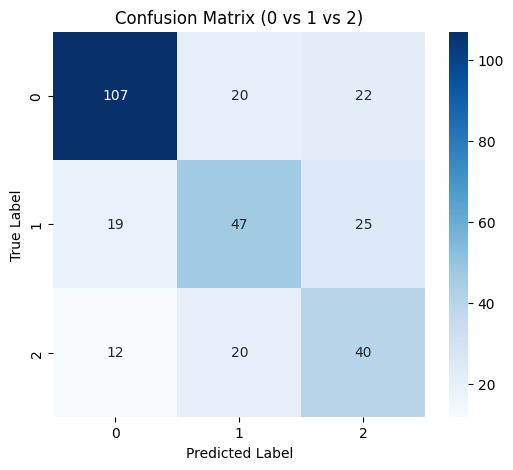

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import time 

# --- 設定 ---
# data変数の定義 (ユーザーのコメントに基づき固定)
data = "1201_humomentstest" 
model = "1201_nomal" 

# === 1, 2. データの読み込みと特徴量定義 ===
merged_data_csv = f"/home/data/{data}/feature.csv"
try:
    df = pd.read_csv(merged_data_csv)
    print(f"✅ データ読み込み成功: {merged_data_csv}")
except FileNotFoundError:
    print(f"❌ ファイルが見つかりません: {merged_data_csv}")
    exit()

# 現在選択されている特徴量
FEATURE_COLUMNS = [ "MSE", "size_count", "R"] 
X = df[FEATURE_COLUMNS]  # 特徴量
y = df["Label"]  # 目的変数

# === 3. 訓練データとテストデータに分割 ===
RANDOM_STATE = 42
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE # 再現性のためrandom_stateを追加
)

# 訓練データとテストデータのクラスごとのカウントを表示
train_counts = y_train_full.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

print("\n--- クラス分布 ---")
print("Train Data Class Distribution:")
print(train_counts)
print("\nTest Data Class Distribution:")
print(test_counts)


# === 4. K-Fold交差検証とハイパーパラメータチューニング ===

print("\n--- 4. K-Fold交差検証とハイパーパラメータチューニング ---")

# class_weight='balanced' を追加して、クラスの不均衡に対応
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=RANDOM_STATE, class_weight='balanced')) 
])

param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1],
    'svm__kernel': ['rbf']
}

start_time = time.time()
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=5, # 5分割を指定
    scoring='f1_macro', # 不均衡データのためF1-macroを使用
    n_jobs=-1 
)

grid_search.fit(X_train_full, y_train_full)
end_time = time.time()

# --- 平均スコアの抽出と表示 ---

# 1. GridSearchCVの結果をDataFrameとして取得
results_df = pd.DataFrame(grid_search.cv_results_)

# 2. 関連する列（パラメータと平均スコア）のみを抽出
mean_scores_df = results_df[[
    'param_svm__C', 
    'param_svm__gamma', 
    'mean_test_score', 
    'std_test_score' # 標準偏差も併せて表示することで信頼度を示す
]].sort_values(by='mean_test_score', ascending=False)

# 3. 平均スコア（F1-macro）を表示
print("\n--- 5分割交差検証 (K-Fold) の全平均スコア ---")
print(f"評価指標: {grid_search.scoring}")
print(f"処理時間: {end_time - start_time:.2f}秒")
print(mean_scores_df.head(10).to_string(index=False)) # 上位10件を表示

# 4. 最適なパラメータとその平均スコアを再確認
best_params_str = ", ".join([f"{k.split('__')[1]}={v}" for k, v in grid_search.best_params_.items()])
print(f"\n🥇 最適なハイパーパラメータ: {best_params_str}")
print(f"🎯 最適なハイパーパラメータでの平均スコア (F1-macro): {grid_search.best_score_:.4f}")

# 5. 最適モデルの取得
best_svm_model = grid_search.best_estimator_

# === 5. 学習済みモデルを保存（最適化されたモデル） ===
model_path = f"svm_model{model}.pkl"
joblib.dump(best_svm_model, model_path)
print(f"\n✅ 最適モデルを保存: {model_path}")

# === 6. 予測と評価 (テストデータで最終評価) ===
y_pred = best_svm_model.predict(X_test)

# レポートを辞書形式で取得
report_dict = classification_report(y_test, y_pred, output_dict=True)

# DataFrameに変換
report_df = pd.DataFrame(report_dict).transpose()

# 表示（必要に応じて四捨五入）
print("\n--- テストデータ評価結果 (Classification Report) ---")
print(report_df.round(4).to_string())

# テストデータと予測結果を結合してCSV保存
test_data_with_results = df.loc[y_test.index].copy()
test_data_with_results['Predicted_Label'] = y_pred

output_path = f"/home/data/{data}/BBBpredicted_results{model}.csv"
test_data_with_results.to_csv(output_path, index=False)
print(f"\n✅ 予測結果をCSVに保存: {output_path}")


# === 7. 混同行列の可視化 ===
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
# ラベルが0, 1, 2であることが多いが、dfのLabelのunique値を使うのが確実
labels = sorted(y_test.unique())
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix ({' vs '.join(map(str, labels))})")
plt.show()

新しい手法（hu moments）

In [ ]:
# run_process.ipynb のセル

# 1. pip install したライブラリをインポート
import maesyori_fast

# 2. パラメータを定義
BASE_DIR = '/home/data/1201_humomentstest' 
MODEL_PATH = '/home/YOLO/0708_maesyori/datasets/train/weights/best.pt'
AREA_THRESHOLD = 50000
TARGET_FOLDERS = ['A', 'B', 'C'] 

# 3. 実行
# (if __name__ == "__main__": は引き続き必要)
if __name__ == "__main__":
    start = time.time()
    maesyori_fast.run(
        base_dir=BASE_DIR,
        model_path=MODEL_PATH,
        target_folders=TARGET_FOLDERS,
        area_threshold=AREA_THRESHOLD,
        max_workers=2
    )
current_time = time.time()
print(f"--- [1. 前処理] 完了 (所要時間: {current_time - start:.2f}秒) ---")

In [12]:

import hida_fast
import keijo_fast
import size_module_fast
import pandas as pd
#判別フェーズ
#特徴量抽出
# data = "1201_humomentstest"
data = "0107_tomine"
hida_tappleA = hida_fast.Hida_folder_jikuari_img_xxxx(base_dir=f"/home/data/{data}",subfolder="A",method="45rotate",n=9,T=0.4)
result_hidaA = hida_tappleA.run_all()
hida_tappleB = hida_fast.Hida_folder_jikuari_img_xxxx(base_dir=f"/home/data/{data}",subfolder="B",method="45rotate",n=9,T=0.4)
result_hidaB = hida_tappleB.run_all()
hida_tappleC = hida_fast.Hida_folder_jikuari_img_xxxx(base_dir=f"/home/data/{data}",subfolder="C",method="45rotate",n=9,T=0.4)
result_hidaC = hida_tappleC.run_all()
dfA = pd.DataFrame(result_hidaA, columns=["filename", "R"])
dfB = pd.DataFrame(result_hidaB, columns=["filename", "R"])
dfC = pd.DataFrame(result_hidaC, columns=["filename", "R"])
dfA ["Label"] = "0"
dfB ["Label"] = "1"
dfC ["Label"] = "2"
result_hida = pd.concat([dfA, dfB, dfC], axis=0,ignore_index=True)
# print(f"Hida_fastの総処理時間: {hida_time:.2f}秒")
size_tappleA = size_module_fast.Size_folder_taikakusen(base_dir=f"/home/data/{data}",subfolder="A")
result_sizeA = size_tappleA.run()
size_tappleB = size_module_fast.Size_folder_taikakusen(base_dir=f"/home/data/{data}",subfolder="B")
result_sizeB = size_tappleB.run()
size_tappleC = size_module_fast.Size_folder_taikakusen(base_dir=f"/home/data/{data}",subfolder="C")
result_sizeC = size_tappleC.run()
dfA = pd.DataFrame(result_sizeA, columns=["filename", "size_count"])                                                    
dfB = pd.DataFrame(result_sizeB, columns=["filename", "size_count"])
dfC = pd.DataFrame(result_sizeC, columns=["filename", "size_count"])
result_size = pd.concat([dfA, dfB, dfC], axis=0,ignore_index=True)


探索対象フォルダ: /home/data/0107_tomine/mask/A
📂 1064 枚の画像をマルチプロセスで処理します。


処理中 (A): 100%|██████████| 1064/1064 [00:11<00:00, 93.31it/s] 

探索対象フォルダ: /home/data/0107_tomine/mask/B
📂 844 枚の画像をマルチプロセスで処理します。



処理中 (B): 100%|██████████| 844/844 [00:09<00:00, 90.14it/s] 

探索対象フォルダ: /home/data/0107_tomine/mask/C
📂 776 枚の画像をマルチプロセスで処理します。



処理中 (C): 100%|██████████| 776/776 [00:08<00:00, 91.71it/s] 


In [3]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import time
# from scipy import stats # 等級判別には不要なので削除

# --- 1. Hu Moments (案4) の分析クラス (変更なし) ---

class KeijoAnalyzer_HuMoments_Flusser:
    """
    シイタケのマスク画像から形状特徴（Hu Moments + Flusserの8番目）を分析する
    """
    def __init__(self):
        pass

    def analyze_hu_moments(self, img_path):
        """
        提案4：7つのHu MomentsとFlusserの8番目の不変量（h7）を計算し、Log変換して返す
        """
        mask = cv2.imread(img_path)
        if mask is None:
            print(f"⚠️ 読み込み失敗: {img_path}")
            return None

        gray = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
        _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            print(f"⚠️ 輪郭なし: {img_path}")
            return None

        max_contour = max(contours, key=cv2.contourArea)
        
        if cv2.contourArea(max_contour) < 10:
             print(f"⚠️ 面積が小さすぎる: {img_path}")
             return None

        # 輪郭からモーメントを計算
        M = cv2.moments(max_contour)
        
        if M["m00"] == 0:
            return None
            
        # Hu Moments (phi_1〜phi_7) を計算
        hu = cv2.HuMoments(M)
        
        # 1. 標準の7つの不変量 (h0〜h6, Log変換)
        # sgn(hu) * log10(|hu|) で、サインを保持しつつスケールを調整
        log_hu_standard = -np.sign(hu) * np.log10(np.abs(hu))
        
        # 2. Flusserの8番目の不変量 (h7) を追加
        # $\phi_7$ (hu[6]) の絶対値を取り、Log変換することで反射不変とする
        phi7_abs = np.abs(hu[6])
        # $\phi_7$は通常非常に小さいため、Log変換でスケールを調整
        log_hu_8th = -np.log10(phi7_abs)
        
        # 3. 8つの不変量を結合して返す (h0〜h7)
        final_hu_vector = np.append(log_hu_standard, log_hu_8th)

        return final_hu_vector.flatten()


class Keijo_folder_HuMoments(KeijoAnalyzer_HuMoments_Flusser):
    """
    指定されたフォルダ内の全画像のHu Moments (h0〜h7)を計算し、リストに保存する (CSV保存機能は削除/変更)
    """
    def __init__(self, base_dir, category, mask_dir="mask", subfolder=None):
        super().__init__()
        # subfolderがNoneの場合はcategoryを使用
        _subfolder = subfolder if subfolder is not None else category
        self.folder_path = os.path.join(base_dir, mask_dir, _subfolder)
        self.category = category # カテゴリ情報を追加
        self.results_list = []

    def run(self):
        image_paths = glob.glob(os.path.join(self.folder_path, "*.jpg")) + \
                      glob.glob(os.path.join(self.folder_path, "*.png"))
        
        print(f"📂 フォルダ({self.category}, Hu Moments + h7): {self.folder_path} に画像 {len(image_paths)} 枚")
        
        self.results_list = []
        column_names = ['filename', 'category'] + [f'h{i}' for i in range(8)]

        for img_path in image_paths:
            file_name = os.path.basename(img_path)
            
            # Hu Moments (h0〜h7) を計算
            hu_vector = self.analyze_hu_moments(img_path)
            
            if hu_vector is not None:
                # ファイル名、カテゴリ、8つのモーメントを結合してリストに追加
                row = [file_name, self.category] + list(hu_vector)
                self.results_list.append(row)
            else:
                # 失敗した場合、NaNで埋める
                self.results_list.append([file_name, self.category] + [np.nan] * 8) 
                
        # 結果をDataFrameとして返す
        df = pd.DataFrame(self.results_list, columns=column_names)
        # 特徴量計算に失敗した行を除外
        return df.dropna(subset=[f'h{i}' for i in range(8)]) 


# --- 2. 等級判別用データ準備関数 ---

def prepare_data_for_classification(base_dir, categories):
    """
    指定されたカテゴリの全画像についてHu Moments特徴量（h0〜h7）を計算し、
    一つのDataFrameに結合して返す。
    """
    start_time = time.time()
    all_dfs = []
    
    print("--- 等級判別用データ準備 (Hu Moments + h7) ---")
    
    for category in categories:
        # Keijo_folder_HuMoments クラスを使用して特徴量を計算
        analyzer = Keijo_folder_HuMoments(
            base_dir=base_dir,
            category=category,
            # mask_dir="mask", # デフォルト値
            subfolder=category # カテゴリ名がサブフォルダ名と一致
        )
        
        df_category = analyzer.run()
        all_dfs.append(df_category)
        print(f"✅ カテゴリ {category} の特徴量 {len(df_category)} 件を抽出完了。")

    # 全カテゴリのデータを結合
    combined_df = pd.concat(all_dfs, ignore_index=True)
    
    total_time = time.time() - start_time
    print(f"\n✨ 全カテゴリのHu Moments特徴量抽出・結合が完了しました。")
    print(f"総処理時間: {total_time:.2f}秒")
    print(f"最終データ件数: {len(combined_df)} 件 (特徴量: h0〜h7)")
    
    return combined_df # 全ての情報を一つのDataFrameとして返す


# --- 3. メイン実行ブロック ---

if __name__ == "__main__":
    
    # --- 設定: 入力元 ---
    # ユーザーの既存のコードから /home/data/{data} の形式を想定
    # 例としてダミーのデータディレクトリを設定します
    # INPUT_DATA_DIR = "/home/data/1124_keijotest"
    
    # ユーザーの既存のコード（Keijo_fast）に合わせて、データディレクトリを変数で設定
    # data = "1124_keijotest" # 判別したいデータセット名に置き換えてください
    INPUT_DATA_DIR = f"/home/data/{data}"
    
    CATEGORIES = ["A", "B", "C"]
    
    start_time = time.time()
    
    # Hu Moments (h0〜h7) の特徴量を結合したDataFrameを作成
    result_hu_moments_df = prepare_data_for_classification(
        base_dir=INPUT_DATA_DIR,
        categories=CATEGORIES
    )
    
    keijo_time = time.time() - start_time
    print(f"\nKeijo_HuMomentsの総処理時間: {keijo_time:.2f}秒")

    # 抽出結果の確認
    print("\n--- 抽出された特徴量データ（先頭5行） ---")
    print(result_hu_moments_df.head())
    
    # ユーザーの既存の出力形式（result_keijo）に合わせた出力例：
    # Hu Momentsの特徴量すべてをそのまま使用するのが最も簡単で強力ですが、
    # もしMSEと同様に単一の特徴量だけを抽出したければ、以下の処理を追加できます。
    # 例：h7だけを抽出
    # result_keijo = result_hu_moments_df[['filename', 'h7']].rename(columns={'h7': 'HU_H7'})
    
    # Hu Momentsの特徴量すべてを含むDataFrameを等級判別用として利用します。
    result_keijo = result_hu_moments_df
    
    print("\n--- 等級判別用の最終データフレーム ---")
    print(result_keijo.head())
    
    # この result_keijo を使って、機械学習モデルで等級判別を行うことができます。

--- 等級判別用データ準備 (Hu Moments + h7) ---
📂 フォルダ(A, Hu Moments + h7): /home/data/0107_tomine/mask/A に画像 1064 枚
✅ カテゴリ A の特徴量 1064 件を抽出完了。
📂 フォルダ(B, Hu Moments + h7): /home/data/0107_tomine/mask/B に画像 844 枚
✅ カテゴリ B の特徴量 844 件を抽出完了。
📂 フォルダ(C, Hu Moments + h7): /home/data/0107_tomine/mask/C に画像 776 枚
✅ カテゴリ C の特徴量 776 件を抽出完了。

✨ 全カテゴリのHu Moments特徴量抽出・結合が完了しました。
総処理時間: 1.83秒
最終データ件数: 2684 件 (特徴量: h0〜h7)

Keijo_HuMomentsの総処理時間: 1.83秒

--- 抽出された特徴量データ（先頭5行） ---
                   filename category        h0        h1        h2        h3  \
0        IMG_66639_mask.png        A  0.793217  3.268768  5.227839  7.575623   
1  IMG_64624_mask_rot30.png        A  0.795550  4.279909  4.644730  7.314919   
2  IMG_66732_mask_rot30.png        A  0.796494  3.811256  6.118911  9.461354   
3  IMG_6467_mask_rot_30.png        A  0.765686  2.414499  5.090521  6.253045   
4        IMG_66627_mask.png        A  0.792293  3.547070  4.348659  6.304316   

          h4         h5         h6         h7  
0 -14.057255  -

In [4]:

df_merged = pd.merge(result_keijo, result_size, on="filename")
df_merged = pd.merge(df_merged, result_hida, on="filename")
df_merged.to_csv(f"/home/data/{data}/feature_huall.csv", index=False)

In [17]:
result_hida.to_csv(f"/home/data/{data}/feature_hida.csv", index=False)
result_keijo.to_csv(f"/home/data/{data}/feature_keijo.csv", index=False)
result_size.to_csv(f"/home/data/{data}/feature_size.csv", index=False)

In [18]:
import pandas as pd
import os

def extend_csv_data():
    # ---------------------------------------------------------
    # 設定: ここにCSVファイルのパスを指定してください
    # ---------------------------------------------------------
    INPUT_CSV_PATH = '/home/data/0107_tomine/feature_hida.csv'   # 元のCSVファイル名
    OUTPUT_CSV_PATH = '/home/data/0107_tomine/extended_feature_hida.csv' # 保存するCSVファイル名
    
    # 追加するサフィックスのリスト
    SUFFIXES = ['_flip', '_rot30', '_rot_30']
    
    # ---------------------------------------------------------
    # 実行処理
    # ---------------------------------------------------------
    # 1. CSV読み込み
    if not os.path.exists(INPUT_CSV_PATH):
        print(f"エラー: ファイルが見つかりません: {INPUT_CSV_PATH}")
        # テスト用にサンプルデータを作成して動作させたい場合は以下をコメントアウト解除
        # df = pd.DataFrame({
        #     'filename': ['IMG_6420_mask.png', 'IMG_6421_mask.png'], 
        #     'R': [0.467, 0.410], 
        #     'Label': [0, 0]
        # })
        return

    print(f"読み込み中: {INPUT_CSV_PATH}")
    df = pd.read_csv(INPUT_CSV_PATH)
    
    # 新しい行を格納するリスト
    new_rows = []

    # 2. 各行に対して拡張データを生成
    for index, row in df.iterrows():
        original_filename = row['filename']
        
        # 拡張子とファイル名を分離 (例: "IMG_6420_mask" と ".png")
        base_name, ext = os.path.splitext(original_filename)
        
        for suffix in SUFFIXES:
            # 新しいファイル名を作成 (例: IMG_6420_mask_flip.png)
            new_filename = f"{base_name}{suffix}{ext}"
            
            # 元の行のデータをコピーしてファイル名だけ書き換え
            new_row = row.copy()
            new_row['filename'] = new_filename
            new_rows.append(new_row)

    # 3. 元のデータと新しいデータを結合
    # pd.concatを使ってDataFrameとして結合
    df_extended = pd.concat([df, pd.DataFrame(new_rows)], ignore_index=True)
    
    # (オプション) ファイル名順にソートすると見やすくなります
    df_extended = df_extended.sort_values(by='filename').reset_index(drop=True)

    # 4. CSV保存
    df_extended.to_csv(OUTPUT_CSV_PATH, index=False)
    print(f"完了しました。保存先: {OUTPUT_CSV_PATH}")
    print(f"元の行数: {len(df)} -> 拡張後の行数: {len(df_extended)}")

if __name__ == '__main__':
    extend_csv_data()

読み込み中: /home/data/0107_tomine/feature_hida.csv
完了しました。保存先: /home/data/0107_tomine/extended_feature_hida.csv
元の行数: 671 -> 拡張後の行数: 2684


In [19]:
hida = pd.read_csv(f"/home/data/{data}/extended_feature_hida.csv")
keijo = pd.read_csv(f"/home/data/{data}/feature_keijo.csv")
size = pd.read_csv(f"/home/data/{data}/feature_size.csv")
df_merged = pd.merge(keijo, size, on="filename")
df_merged = pd.merge(df_merged, hida, on="filename")
df_merged.to_csv(f"/home/data/{data}/feature_huall.csv", index=False)

In [21]:
print(len(df_merged))

2684


✅ データ読み込み成功: /home/data/1201_humomentstest/feature_huall.csv

--- クラス分布 ---
Train Data Class Distribution:
Label
0    347
1    211
2    168
Name: count, dtype: int64

Test Data Class Distribution:
Label
0    149
1     91
2     72
Name: count, dtype: int64

--- 4. K-Fold交差検証とハイパーパラメータチューニング ---

--- 5分割交差検証 (K-Fold) の全平均スコア ---
評価指標: f1_macro
処理時間: 0.93秒
 param_svm__C param_svm__gamma  mean_test_score  std_test_score
        100.0             0.01         0.630582        0.020714
         10.0              0.1         0.625666        0.014187
          1.0            scale         0.624133        0.024802
          1.0             auto         0.624133        0.024802
          1.0              0.1         0.623804        0.017120
         10.0             0.01         0.620842        0.029312
          0.1            scale         0.611130        0.022515
          0.1             auto         0.611130        0.022515
         10.0            scale         0.610752        0.015388
    

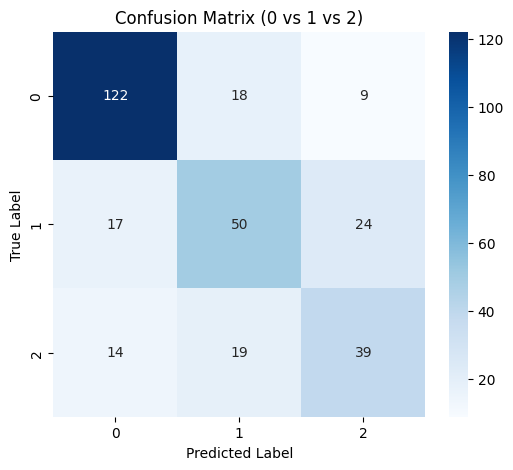

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import time 

# --- 設定 ---
# data変数の定義 (ユーザーのコメントに基づき固定)
data = "1201_humomentstest" 
model = "1201_HuMoments_h0h2h3h7sizeR_balanced" 

# === 1, 2. データの読み込みと特徴量定義 ===
merged_data_csv = f"/home/data/{data}/feature_huall.csv"
try:
    df = pd.read_csv(merged_data_csv)
    print(f"✅ データ読み込み成功: {merged_data_csv}")
except FileNotFoundError:
    print(f"❌ ファイルが見つかりません: {merged_data_csv}")
    exit()

# 現在選択されている特徴量
FEATURE_COLUMNS = [ "h0","h2", "h3","h7", "size_count", "R"] 
X = df[FEATURE_COLUMNS]  # 特徴量
y = df["Label"]  # 目的変数

# === 3. 訓練データとテストデータに分割 ===
RANDOM_STATE = 42
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE # 再現性のためrandom_stateを追加
)

# 訓練データとテストデータのクラスごとのカウントを表示
train_counts = y_train_full.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

print("\n--- クラス分布 ---")
print("Train Data Class Distribution:")
print(train_counts)
print("\nTest Data Class Distribution:")
print(test_counts)


# === 4. K-Fold交差検証とハイパーパラメータチューニング ===

print("\n--- 4. K-Fold交差検証とハイパーパラメータチューニング ---")

# class_weight='balanced' を追加して、クラスの不均衡に対応
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=RANDOM_STATE, class_weight='balanced')) 
])

param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1],
    'svm__kernel': ['rbf']
}

start_time = time.time()
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=5, # 5分割を指定
    scoring='f1_macro', # 不均衡データのためF1-macroを使用
    n_jobs=-1 
)

grid_search.fit(X_train_full, y_train_full)
end_time = time.time()

# --- 平均スコアの抽出と表示 ---

# 1. GridSearchCVの結果をDataFrameとして取得
results_df = pd.DataFrame(grid_search.cv_results_)

# 2. 関連する列（パラメータと平均スコア）のみを抽出
mean_scores_df = results_df[[
    'param_svm__C', 
    'param_svm__gamma', 
    'mean_test_score', 
    'std_test_score' # 標準偏差も併せて表示することで信頼度を示す
]].sort_values(by='mean_test_score', ascending=False)

# 3. 平均スコア（F1-macro）を表示
print("\n--- 5分割交差検証 (K-Fold) の全平均スコア ---")
print(f"評価指標: {grid_search.scoring}")
print(f"処理時間: {end_time - start_time:.2f}秒")
print(mean_scores_df.head(10).to_string(index=False)) # 上位10件を表示

# 4. 最適なパラメータとその平均スコアを再確認
best_params_str = ", ".join([f"{k.split('__')[1]}={v}" for k, v in grid_search.best_params_.items()])
print(f"\n🥇 最適なハイパーパラメータ: {best_params_str}")
print(f"🎯 最適なハイパーパラメータでの平均スコア (F1-macro): {grid_search.best_score_:.4f}")

# 5. 最適モデルの取得
best_svm_model = grid_search.best_estimator_

# === 5. 学習済みモデルを保存（最適化されたモデル） ===
model_path = f"svm_model{model}.pkl"
joblib.dump(best_svm_model, model_path)
print(f"\n✅ 最適モデルを保存: {model_path}")

# === 6. 予測と評価 (テストデータで最終評価) ===
y_pred = best_svm_model.predict(X_test)

# レポートを辞書形式で取得
report_dict = classification_report(y_test, y_pred, output_dict=True)

# DataFrameに変換
report_df = pd.DataFrame(report_dict).transpose()

# 表示（必要に応じて四捨五入）
print("\n--- テストデータ評価結果 (Classification Report) ---")
print(report_df.round(4).to_string())

# テストデータと予測結果を結合してCSV保存
test_data_with_results = df.loc[y_test.index].copy()
test_data_with_results['Predicted_Label'] = y_pred

output_path = f"/home/data/{data}/BBBpredicted_results{model}.csv"
test_data_with_results.to_csv(output_path, index=False)
print(f"\n✅ 予測結果をCSVに保存: {output_path}")


# === 7. 混同行列の可視化 ===
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
# ラベルが0, 1, 2であることが多いが、dfのLabelのunique値を使うのが確実
labels = sorted(y_test.unique())
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix ({' vs '.join(map(str, labels))})")
plt.show()

全組み合わせ

In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import time 
import itertools # 全組み合わせを生成するために使用

# 例: data変数の定義（既存のコードに合わせてください）
# data = "1124_keijotest" 
model = "1201_HuMoments_h7_ALL_COMBS" # モデル名を変更

# --- 1. データの読み込みと特徴量定義 ---
merged_data_csv = f"/home/data/{data}/feature_huall.csv"
try:
    df = pd.read_csv(merged_data_csv)
    print(f"✅ データ読み込み成功: {merged_data_csv}")
except FileNotFoundError:
    print(f"❌ ファイルが見つかりません: {merged_data_csv}")
    raise # ファイルがない場合は処理を中断

# 全特徴量の定義 (10個)
ALL_FEATURES = ["h0", "h1", "h2", "h3", "h4", "h5", "h6", "h7", "size_count", "R"]
TARGET = "Label"
RANDOM_STATE = 42

# 特徴量列の存在確認とリストの調整
missing_features = [f for f in ALL_FEATURES if f not in df.columns]
if missing_features:
    print(f"⚠️ 以下の特徴量が見つかりません: {missing_features}。これらの特徴量は除外します。")
    ALL_FEATURES = [f for f in ALL_FEATURES if f not in missing_features]
    print(f"使用する特徴量リスト: {ALL_FEATURES} ({len(ALL_FEATURES)}個)")
    
NUM_FEATURES = len(ALL_FEATURES)
TOTAL_COMBINATIONS = sum([len(list(itertools.combinations(ALL_FEATURES, r))) for r in range(1, NUM_FEATURES + 1)])
print(f"🔍 総探索組み合わせ数: {TOTAL_COMBINATIONS} 通り")


# --- 2. ハイパーパラメータグリッド ---
# 総当たり探索のため、計算時間を考慮し、ハイパーパラメータの選択肢を絞っています。
PARAM_GRID = {
    'C': [0.1, 1, 10], 
    'gamma': ['scale', 0.1] # 'auto' を削除し、さらに絞ることも可能です
}

# --- 3. 評価関数（GridSearchCVの実行）---

def evaluate_features_set(features, param_grid):
    """
    指定された特徴量セットでGridSearchCVを実行し、最良の平均交差検証スコアを返します。
    """
    X = df[list(features)] # タプルをリストに変換
    y = df[TARGET]

    # データ分割（GridSearchCVは訓練データのみを使用）
    X_train_full, _, y_train_full, _ = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE
    )

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(random_state=RANDOM_STATE)) 
    ])

    param_grid_pipeline = {f'svm__{k}': v for k, v in param_grid.items()}
    param_grid_pipeline['svm__kernel'] = ['rbf'] 

    grid_search = GridSearchCV(
        pipeline, 
        param_grid_pipeline, 
        cv=5, 
        scoring='f1_macro', 
        n_jobs=-1,
        verbose=0 # 出力を抑制
    )
    grid_search.fit(X_train_full, y_train_full)
    
    return grid_search.best_score_

# --- 4. 総当たり探索の実行 ---

print("\n--- 総当たり特徴量探索の実行 ---")
start_time_full_search = time.time()

best_overall_score = -np.inf
best_overall_features = None
results_list = []
current_count = 0

# 特徴量数 r = 1 から 最大数 までループ
for r in range(1, NUM_FEATURES + 1):
    
    # r個の特徴量のすべての組み合わせを生成
    for features_tuple in itertools.combinations(ALL_FEATURES, r):
        current_count += 1
        
        # 評価を実行
        score = evaluate_features_set(features_tuple, PARAM_GRID)
        
        features_str = ', '.join(features_tuple)
        
        results_list.append({
            'features_str': features_str,
            'num_features': r,
            'score': score
        })

        if score > best_overall_score:
            best_overall_score = score
            best_overall_features = features_str
            print(f"🏆 NEW BEST! スコア: {score:.4f}, 特徴量 ({r}個): {features_str}")
        
        # 進行状況を時々表示
        if current_count % 100 == 0 or current_count == TOTAL_COMBINATIONS:
             print(f"  [進捗] {current_count} / {TOTAL_COMBINATIONS} 完了 ({((current_count / TOTAL_COMBINATIONS) * 100):.1f}%)")


end_time_full_search = time.time()

# --- 5. 結果の表示と保存 ---

total_duration = end_time_full_search - start_time_full_search
print("\n--- 総当たり探索結果まとめ ---")
print(f"総処理時間: {total_duration:.2f}秒")

final_results_df = pd.DataFrame(results_list).sort_values(
    by='score', 
    ascending=False
)

print("\n🥇 最も高いスコアを達成した特徴量セット (平均 F1-macro スコア):")
print(f"   使用特徴量: {best_overall_features}")
print(f"   平均スコア: {best_overall_score:.4f}")

# 全結果をCSVとして保存
output_csv_path = f"/home/data/{data}/full_search_results_{model}.csv"
final_results_df.to_csv(output_csv_path, index=False)
print(f"\n✅ 全組み合わせの結果をCSVに保存しました: {output_csv_path}")

✅ データ読み込み成功: /home/data/1201_humomentstest/feature_huall.csv
🔍 総探索組み合わせ数: 1023 通り

--- 総当たり特徴量探索の実行 ---
🏆 NEW BEST! スコア: 0.2773, 特徴量 (1個): h0
🏆 NEW BEST! スコア: 0.4355, 特徴量 (1個): size_count
🏆 NEW BEST! スコア: 0.5291, 特徴量 (2個): h0, size_count
🏆 NEW BEST! スコア: 0.5403, 特徴量 (2個): h1, size_count
🏆 NEW BEST! スコア: 0.5465, 特徴量 (2個): h3, size_count
🏆 NEW BEST! スコア: 0.5503, 特徴量 (2個): h7, size_count
🏆 NEW BEST! スコア: 0.5816, 特徴量 (2個): size_count, R
🏆 NEW BEST! スコア: 0.5893, 特徴量 (3個): h0, size_count, R
  [進捗] 100 / 1023 完了 (9.8%)
🏆 NEW BEST! スコア: 0.6065, 特徴量 (3個): h2, size_count, R
  [進捗] 200 / 1023 完了 (19.6%)
🏆 NEW BEST! スコア: 0.6116, 特徴量 (4個): h0, h2, size_count, R
🏆 NEW BEST! スコア: 0.6117, 特徴量 (4個): h0, h3, size_count, R
🏆 NEW BEST! スコア: 0.6146, 特徴量 (4個): h0, h7, size_count, R
  [進捗] 300 / 1023 完了 (29.3%)
  [進捗] 400 / 1023 完了 (39.1%)
🏆 NEW BEST! スコア: 0.6200, 特徴量 (5個): h0, h2, h3, size_count, R
🏆 NEW BEST! スコア: 0.6201, 特徴量 (5個): h0, h2, h4, size_count, R
🏆 NEW BEST! スコア: 0.6226, 特徴量 (5個): h0, h2, h7, si

In [45]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import time 
import itertools 

# 例: data変数の定義（既存のコードに合わせてください）
# data = "1124_keijotest" 
model = "1201_HuMoments_h7_ALL_COMBS_ACC" # モデル名をAccuracy版に変更

# --- 1. データの読み込みと特徴量定義 ---
merged_data_csv = f"/home/data/{data}/feature_huall.csv"
try:
    df = pd.read_csv(merged_data_csv)
    print(f"✅ データ読み込み成功: {merged_data_csv}")
except FileNotFoundError:
    print(f"❌ ファイルが見つかりません: {merged_data_csv}")
    raise # ファイルがない場合は処理を中断

# 全特徴量の定義 (10個)
ALL_FEATURES = ["h0", "h1", "h2", "h3", "h4", "h5", "h6", "h7", "size_count", "R"]
TARGET = "Label"
RANDOM_STATE = 42

# 特徴量列の存在確認とリストの調整
missing_features = [f for f in ALL_FEATURES if f not in df.columns]
if missing_features:
    print(f"⚠️ 以下の特徴量が見つかりません: {missing_features}。これらの特徴量は除外します。")
    ALL_FEATURES = [f for f in ALL_FEATURES if f not in missing_features]
    print(f"使用する特徴量リスト: {ALL_FEATURES} ({len(ALL_FEATURES)}個)")
    
NUM_FEATURES = len(ALL_FEATURES)
TOTAL_COMBINATIONS = sum([len(list(itertools.combinations(ALL_FEATURES, r))) for r in range(1, NUM_FEATURES + 1)])
print(f"🔍 総探索組み合わせ数: {TOTAL_COMBINATIONS} 通り")


# --- 2. ハイパーパラメータグリッド ---
# 計算時間を考慮し、GridSearchCVの選択肢を絞っています。
PARAM_GRID = {
    'C': [0.1, 1, 10], 
    'gamma': ['scale', 0.1]
}

# --- 3. 評価関数（GridSearchCVの実行）---

def evaluate_features_set(features, param_grid):
    """
    指定された特徴量セットでGridSearchCVを実行し、
    最良の平均交差検証スコア (Accuracy) を返します。
    """
    X = df[list(features)] # タプルをリストに変換
    y = df[TARGET]

    # データ分割（GridSearchCVは訓練データのみを使用）
    X_train_full, _, y_train_full, _ = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE
    )

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(random_state=RANDOM_STATE)) 
    ])

    param_grid_pipeline = {f'svm__{k}': v for k, v in param_grid.items()}
    param_grid_pipeline['svm__kernel'] = ['rbf'] 

    grid_search = GridSearchCV(
        pipeline, 
        param_grid_pipeline, 
        cv=5, 
        scoring='accuracy', # 評価指標を 'accuracy' に変更
        n_jobs=-1,
        verbose=0 
    )
    grid_search.fit(X_train_full, y_train_full)
    
    return grid_search.best_score_

# --- 4. 総当たり探索の実行 ---

print("\n--- 総当たり特徴量探索の実行 (Accuracy) ---")
start_time_full_search = time.time()

best_overall_score = -np.inf
best_overall_features = None
results_list = []
current_count = 0

# 特徴量数 r = 1 から 最大数 までループ
for r in range(1, NUM_FEATURES + 1):
    
    # r個の特徴量のすべての組み合わせを生成
    for features_tuple in itertools.combinations(ALL_FEATURES, r):
        current_count += 1
        
        # 評価を実行
        score = evaluate_features_set(features_tuple, PARAM_GRID)
        
        features_str = ', '.join(features_tuple)
        
        results_list.append({
            'features_str': features_str,
            'num_features': r,
            'score': score
        })

        if score > best_overall_score:
            best_overall_score = score
            best_overall_features = features_str
            print(f"🏆 NEW BEST! スコア (Accuracy): {score:.4f}, 特徴量 ({r}個): {features_str}")
        
        # 進行状況を時々表示
        if current_count % 100 == 0 or current_count == TOTAL_COMBINATIONS:
             print(f"  [進捗] {current_count} / {TOTAL_COMBINATIONS} 完了 ({((current_count / TOTAL_COMBINATIONS) * 100):.1f}%)")


end_time_full_search = time.time()

# --- 5. 結果の表示と保存 ---

total_duration = end_time_full_search - start_time_full_search
print("\n--- 総当たり探索結果まとめ ---")
print(f"総処理時間: {total_duration:.2f}秒")

final_results_df = pd.DataFrame(results_list).sort_values(
    by='score', 
    ascending=False
)

print("\n🥇 最も高いスコアを達成した特徴量セット (平均 Accuracy):")
print(f"   使用特徴量: {best_overall_features}")
print(f"   平均スコア: {best_overall_score:.4f}")

# 全結果をCSVとして保存
output_csv_path = f"/home/data/{data}/full_search_results_accuracy_{model}.csv"
final_results_df.to_csv(output_csv_path, index=False)
print(f"\n✅ 全組み合わせの結果をCSVに保存しました: {output_csv_path}")

✅ データ読み込み成功: /home/data/1201_humomentstest/feature_huall.csv
🔍 総探索組み合わせ数: 1023 通り

--- 総当たり特徴量探索の実行 (Accuracy) ---
🏆 NEW BEST! スコア (Accuracy): 0.4848, 特徴量 (1個): h0
🏆 NEW BEST! スコア (Accuracy): 0.5868, 特徴量 (1個): size_count
🏆 NEW BEST! スコア (Accuracy): 0.6116, 特徴量 (2個): h0, size_count
🏆 NEW BEST! スコア (Accuracy): 0.6143, 特徴量 (2個): h1, size_count
🏆 NEW BEST! スコア (Accuracy): 0.6170, 特徴量 (2個): h3, size_count
🏆 NEW BEST! スコア (Accuracy): 0.6184, 特徴量 (2個): h5, size_count
🏆 NEW BEST! スコア (Accuracy): 0.6226, 特徴量 (2個): h7, size_count
🏆 NEW BEST! スコア (Accuracy): 0.6391, 特徴量 (2個): size_count, R
🏆 NEW BEST! スコア (Accuracy): 0.6391, 特徴量 (3個): h0, size_count, R
  [進捗] 100 / 1023 完了 (9.8%)
🏆 NEW BEST! スコア (Accuracy): 0.6598, 特徴量 (3個): h2, size_count, R
  [進捗] 200 / 1023 完了 (19.6%)
🏆 NEW BEST! スコア (Accuracy): 0.6612, 特徴量 (4個): h0, h2, size_count, R
  [進捗] 300 / 1023 完了 (29.3%)
🏆 NEW BEST! スコア (Accuracy): 0.6639, 特徴量 (4個): h2, h6, size_count, R
  [進捗] 400 / 1023 完了 (39.1%)
🏆 NEW BEST! スコア (Accuracy): 0.6639,

案2：扁平度

In [26]:
import hida_fast
import keijo_fast
import size_module_fast
#特徴量抽出
data = "1201_humomentstest"
hida_tappleA = hida_fast.Hida_folder_jikuari_img_xxxx(base_dir=f"/home/data/{data}",subfolder="A",method="45rotate",n=9,T=0.4)
result_hidaA = hida_tappleA.run_all()
hida_tappleB = hida_fast.Hida_folder_jikuari_img_xxxx(base_dir=f"/home/data/{data}",subfolder="B",method="45rotate",n=9,T=0.4)
result_hidaB = hida_tappleB.run_all()
hida_tappleC = hida_fast.Hida_folder_jikuari_img_xxxx(base_dir=f"/home/data/{data}",subfolder="C",method="45rotate",n=9,T=0.4)
result_hidaC = hida_tappleC.run_all()
dfA = pd.DataFrame(result_hidaA, columns=["filename", "R"])
dfB = pd.DataFrame(result_hidaB, columns=["filename", "R"])
dfC = pd.DataFrame(result_hidaC, columns=["filename", "R"])
dfA ["Label"] = "0"
dfB ["Label"] = "1"
dfC ["Label"] = "2"
result_hida = pd.concat([dfA, dfB, dfC], axis=0,ignore_index=True)
hida_time = time.time() - start
print(f"Hida_fastの総処理時間: {hida_time:.2f}秒")
size_tappleA = size_module_fast.Size_folder_taikakusen(base_dir=f"/home/data/{data}",subfolder="A")
result_sizeA = size_tappleA.run()
size_tappleB = size_module_fast.Size_folder_taikakusen(base_dir=f"/home/data/{data}",subfolder="B")
result_sizeB = size_tappleB.run()
size_tappleC = size_module_fast.Size_folder_taikakusen(base_dir=f"/home/data/{data}",subfolder="C")
result_sizeC = size_tappleC.run()
dfA = pd.DataFrame(result_sizeA, columns=["filename", "size_count"])                                                    
dfB = pd.DataFrame(result_sizeB, columns=["filename", "size_count"])
dfC = pd.DataFrame(result_sizeC, columns=["filename", "size_count"])
result_size = pd.concat([dfA, dfB, dfC], axis=0,ignore_index=True)
size_time = time.time() - start
print(f"Size_module_fastの総処理時間: {size_time:.2f}秒")

Hida_fastの総処理時間: 64496.58秒
探索対象フォルダ: /home/data/1201_humomentstest/mask/A
📂 496 枚の画像をマルチプロセスで処理します。


処理中 (A): 100%|██████████| 496/496 [00:05<00:00, 91.33it/s] 


探索対象フォルダ: /home/data/1201_humomentstest/mask/B
📂 302 枚の画像をマルチプロセスで処理します。


処理中 (B): 100%|██████████| 302/302 [00:03<00:00, 76.53it/s] 


探索対象フォルダ: /home/data/1201_humomentstest/mask/C
📂 240 枚の画像をマルチプロセスで処理します。


処理中 (C): 100%|██████████| 240/240 [00:03<00:00, 71.51it/s] 


Size_module_fastの総処理時間: 64510.24秒


In [27]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import time
# matplotlib, scipy, sklearn.metrics は等級判別用データ準備には不要なので削除

# --- 1. 偏平率 (案2) の分析クラス ---

class KeijoAnalyzer_Eccentricity:
    """
    シイタケのマスク画像から形状特徴（偏平率）を分析する
    """
    def __init__(self):
        pass

    def analyze_eccentricity(self, img_path):
        """
        提案2：偏平率 (Eccentricity) を計算し、返す (単一画像処理)
        """
        mask = cv2.imread(img_path)
        if mask is None:
            # print(f"⚠️ 読み込み失敗: {img_path}")
            return None

        gray = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
        _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            # print(f"⚠️ 輪郭なし: {img_path}")
            return None

        max_contour = max(contours, key=cv2.contourArea)

        if len(max_contour) < 5:
            # print(f"⚠️ 輪郭の点が少なすぎます: {img_path}")
            return None

        try:
            # 楕円をフィッティング
            (x, y), (minor_axis, major_axis), angle = cv2.fitEllipse(max_contour)
        except cv2.error as e:
            # print(f"⚠️ cv2.fitEllipse エラー: {e} ({img_path})")
            return None

        if major_axis == 0:
            # print(f"⚠️ 楕円の長軸がゼロです: {img_path}")
            return None # ゼロ除算を避ける

        # 偏平率を計算: eccentricity = sqrt(1 - (b/a)^2)
        eccentricity = np.sqrt(1 - (minor_axis / major_axis)**2)

        return eccentricity


class Keijo_folder_Eccentricity(KeijoAnalyzer_Eccentricity):
    """
    指定されたフォルダ内の全画像の偏平率を計算し、DataFrameとして返す (フォルダ処理)
    """
    def __init__(self, base_dir, category, mask_dir="mask", subfolder=None):
        super().__init__()
        _subfolder = subfolder if subfolder is not None else category
        self.folder_path = os.path.join(base_dir, mask_dir, _subfolder)
        self.category = category 
        self.results_list = []

    def run(self):
        image_paths = glob.glob(os.path.join(self.folder_path, "*.jpg")) + \
                      glob.glob(os.path.join(self.folder_path, "*.png"))
        
        print(f"📂 フォルダ({self.category}, 偏平率): {self.folder_path} に画像 {len(image_paths)} 枚")
        
        self.results_list = []
        column_names = ['filename', 'category', 'eccentricity']

        for img_path in image_paths:
            file_name = os.path.basename(img_path)
            
            # 偏平率を計算
            ecc = self.analyze_eccentricity(img_path)
            
            if ecc is not None:
                self.results_list.append([file_name, self.category, ecc])
            else:
                self.results_list.append([file_name, self.category, np.nan])
                
        # 結果をDataFrameとして返す
        df = pd.DataFrame(self.results_list, columns=column_names)
        # 偏平率の計算に失敗した行（NaN）を除外
        return df.dropna(subset=['eccentricity']) 


# --- 2. 等級判別用データ準備関数 ---

def prepare_data_for_classification_ecc(base_dir, categories):
    """
    指定されたカテゴリの全画像について偏平率を計算し、
    一つのDataFrameに結合して返す。
    """
    start_time = time.time()
    all_dfs = []
    
    print("--- 等級判別用データ準備 (偏平率) ---")
    
    for category in categories:
        # Keijo_folder_Eccentricity クラスを使用して特徴量を計算
        analyzer = Keijo_folder_Eccentricity(
            base_dir=base_dir,
            category=category,
            subfolder=category 
        )
        
        df_category = analyzer.run()
        all_dfs.append(df_category)
        print(f"✅ カテゴリ {category} の特徴量 {len(df_category)} 件を抽出完了。")

    # 全カテゴリのデータを結合
    combined_df = pd.concat(all_dfs, ignore_index=True)
    
    total_time = time.time() - start_time
    print(f"\n✨ 全カテゴリの偏平率特徴量抽出・結合が完了しました。")
    print(f"総処理時間: {total_time:.2f}秒")
    print(f"最終データ件数: {len(combined_df)} 件 (特徴量: eccentricity)")
    
    return combined_df


# --- 3. メイン実行ブロック ---

if __name__ == "__main__":
    
    # --- 設定: 入力元 ---
    # ユーザーの既存のコードに合わせて、データディレクトリを変数で設定
    # data = "1124_keijotest" # 判別したいデータセット名に置き換えてください
    INPUT_DATA_DIR = f"/home/data/{data}"
    
    CATEGORIES = ["A", "B", "C"]
    
    start_time = time.time()
    
    # 偏平率の特徴量を結合したDataFrameを作成
    result_eccentricity_df = prepare_data_for_classification_ecc(
        base_dir=INPUT_DATA_DIR,
        categories=CATEGORIES
    )
    
    keijo_time = time.time() - start_time
    print(f"\nKeijo_Eccentricityの総処理時間: {keijo_time:.2f}秒")

    # 抽出結果の確認
    print("\n--- 抽出された特徴量データ（先頭5行） ---")
    print(result_eccentricity_df.head())
    
    # 既存の出力形式（result_keijo）に合わせて変数名を定義
    result_keijo = result_eccentricity_df
    
    print("\n--- 等級判別用の最終データフレーム ---")
    # filename, category, eccentricity の列が揃っています
    print(result_keijo.head())
    
    # この result_keijo を使って、機械学習モデルで等級判別を行うことができます。

--- 等級判別用データ準備 (偏平率) ---
📂 フォルダ(A, 偏平率): /home/data/1201_humomentstest/mask/A に画像 496 枚
✅ カテゴリ A の特徴量 496 件を抽出完了。
📂 フォルダ(B, 偏平率): /home/data/1201_humomentstest/mask/B に画像 302 枚
✅ カテゴリ B の特徴量 302 件を抽出完了。
📂 フォルダ(C, 偏平率): /home/data/1201_humomentstest/mask/C に画像 240 枚
✅ カテゴリ C の特徴量 240 件を抽出完了。

✨ 全カテゴリの偏平率特徴量抽出・結合が完了しました。
総処理時間: 0.72秒
最終データ件数: 1038 件 (特徴量: eccentricity)

Keijo_Eccentricityの総処理時間: 0.72秒

--- 抽出された特徴量データ（先頭5行） ---
             filename category  eccentricity
0  IMG_66639_mask.png        A      0.502064
1  IMG_66517_mask.png        A      0.303452
2  IMG_66627_mask.png        A      0.428802
3   IMG_6664_mask.png        A      0.704799
4  IMG_64219_mask.png        A      0.638448

--- 等級判別用の最終データフレーム ---
             filename category  eccentricity
0  IMG_66639_mask.png        A      0.502064
1  IMG_66517_mask.png        A      0.303452
2  IMG_66627_mask.png        A      0.428802
3   IMG_6664_mask.png        A      0.704799
4  IMG_64219_mask.png        A      0.638448


In [30]:
df_merged = pd.merge(result_keijo, result_size, on="filename")
df_merged = pd.merge(df_merged, result_hida, on="filename")
df_merged.to_csv(f"/home/data/{data}/feature_eccentricity.csv", index=False)

✅ データ読み込み成功: /home/data/1201_humomentstest/feature_eccentricity.csv

--- クラス分布 ---
Train Data Class Distribution:
Label
0    347
1    211
2    168
Name: count, dtype: int64

Test Data Class Distribution:
Label
0    149
1     91
2     72
Name: count, dtype: int64

--- 4. K-Fold交差検証とハイパーパラメータチューニング ---

--- 5分割交差検証 (K-Fold) の全平均スコア ---
評価指標: f1_macro
処理時間: 0.09秒
 param_svm__C param_svm__gamma  mean_test_score  std_test_score
         10.0            scale         0.603515        0.037816
         10.0             auto         0.603515        0.037816
          1.0            scale         0.603296        0.041533
          1.0             auto         0.603296        0.041533
         10.0              0.1         0.599377        0.028979
        100.0             0.01         0.599244        0.026264
        100.0              0.1         0.598857        0.032636
          1.0             0.01         0.596552        0.061773
          1.0              0.1         0.595850        0.0356

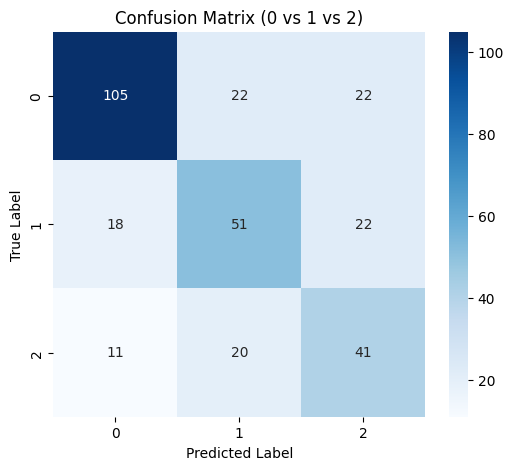

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import time 

# --- 設定 ---
# data変数の定義 (ユーザーのコメントに基づき固定)
data = "1201_humomentstest" 
model = "1201_eccentricity" 

# === 1, 2. データの読み込みと特徴量定義 ===
merged_data_csv = f"/home/data/{data}/feature_eccentricity.csv"
try:
    df = pd.read_csv(merged_data_csv)
    print(f"✅ データ読み込み成功: {merged_data_csv}")
except FileNotFoundError:
    print(f"❌ ファイルが見つかりません: {merged_data_csv}")
    exit()

# 現在選択されている特徴量
FEATURE_COLUMNS = [ "eccentricity", "size_count", "R"] 
X = df[FEATURE_COLUMNS]  # 特徴量
y = df["Label"]  # 目的変数

# === 3. 訓練データとテストデータに分割 ===
RANDOM_STATE = 42
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE # 再現性のためrandom_stateを追加
)

# 訓練データとテストデータのクラスごとのカウントを表示
train_counts = y_train_full.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

print("\n--- クラス分布 ---")
print("Train Data Class Distribution:")
print(train_counts)
print("\nTest Data Class Distribution:")
print(test_counts)


# === 4. K-Fold交差検証とハイパーパラメータチューニング ===

print("\n--- 4. K-Fold交差検証とハイパーパラメータチューニング ---")

# class_weight='balanced' を追加して、クラスの不均衡に対応
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=RANDOM_STATE, class_weight='balanced')) 
])

param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1],
    'svm__kernel': ['rbf']
}

start_time = time.time()
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=5, # 5分割を指定
    scoring='f1_macro', # 不均衡データのためF1-macroを使用
    n_jobs=-1 
)

grid_search.fit(X_train_full, y_train_full)
end_time = time.time()

# --- 平均スコアの抽出と表示 ---

# 1. GridSearchCVの結果をDataFrameとして取得
results_df = pd.DataFrame(grid_search.cv_results_)

# 2. 関連する列（パラメータと平均スコア）のみを抽出
mean_scores_df = results_df[[
    'param_svm__C', 
    'param_svm__gamma', 
    'mean_test_score', 
    'std_test_score' # 標準偏差も併せて表示することで信頼度を示す
]].sort_values(by='mean_test_score', ascending=False)

# 3. 平均スコア（F1-macro）を表示
print("\n--- 5分割交差検証 (K-Fold) の全平均スコア ---")
print(f"評価指標: {grid_search.scoring}")
print(f"処理時間: {end_time - start_time:.2f}秒")
print(mean_scores_df.head(10).to_string(index=False)) # 上位10件を表示

# 4. 最適なパラメータとその平均スコアを再確認
best_params_str = ", ".join([f"{k.split('__')[1]}={v}" for k, v in grid_search.best_params_.items()])
print(f"\n🥇 最適なハイパーパラメータ: {best_params_str}")
print(f"🎯 最適なハイパーパラメータでの平均スコア (F1-macro): {grid_search.best_score_:.4f}")

# 5. 最適モデルの取得
best_svm_model = grid_search.best_estimator_

# === 5. 学習済みモデルを保存（最適化されたモデル） ===
model_path = f"svm_model{model}.pkl"
joblib.dump(best_svm_model, model_path)
print(f"\n✅ 最適モデルを保存: {model_path}")

# === 6. 予測と評価 (テストデータで最終評価) ===
y_pred = best_svm_model.predict(X_test)

# レポートを辞書形式で取得
report_dict = classification_report(y_test, y_pred, output_dict=True)

# DataFrameに変換
report_df = pd.DataFrame(report_dict).transpose()

# 表示（必要に応じて四捨五入）
print("\n--- テストデータ評価結果 (Classification Report) ---")
print(report_df.round(4).to_string())

# テストデータと予測結果を結合してCSV保存
test_data_with_results = df.loc[y_test.index].copy()
test_data_with_results['Predicted_Label'] = y_pred

output_path = f"/home/data/{data}/BBBpredicted_results{model}.csv"
test_data_with_results.to_csv(output_path, index=False)
print(f"\n✅ 予測結果をCSVに保存: {output_path}")


# === 7. 混同行列の可視化 ===
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
# ラベルが0, 1, 2であることが多いが、dfのLabelのunique値を使うのが確実
labels = sorted(y_test.unique())
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix ({' vs '.join(map(str, labels))})")
plt.show()

案5：フーリエ

In [32]:
import hida_fast
import keijo_fast
import size_module_fast
#特徴量抽出
data = "1201_humomentstest"
hida_tappleA = hida_fast.Hida_folder_jikuari_img_xxxx(base_dir=f"/home/data/{data}",subfolder="A",method="45rotate",n=9,T=0.4)
result_hidaA = hida_tappleA.run_all()
hida_tappleB = hida_fast.Hida_folder_jikuari_img_xxxx(base_dir=f"/home/data/{data}",subfolder="B",method="45rotate",n=9,T=0.4)
result_hidaB = hida_tappleB.run_all()
hida_tappleC = hida_fast.Hida_folder_jikuari_img_xxxx(base_dir=f"/home/data/{data}",subfolder="C",method="45rotate",n=9,T=0.4)
result_hidaC = hida_tappleC.run_all()
dfA = pd.DataFrame(result_hidaA, columns=["filename", "R"])
dfB = pd.DataFrame(result_hidaB, columns=["filename", "R"])
dfC = pd.DataFrame(result_hidaC, columns=["filename", "R"])
dfA ["Label"] = "0"
dfB ["Label"] = "1"
dfC ["Label"] = "2"
result_hida = pd.concat([dfA, dfB, dfC], axis=0,ignore_index=True)
hida_time = time.time() - start
print(f"Hida_fastの総処理時間: {hida_time:.2f}秒")
size_tappleA = size_module_fast.Size_folder_taikakusen(base_dir=f"/home/data/{data}",subfolder="A")
result_sizeA = size_tappleA.run()
size_tappleB = size_module_fast.Size_folder_taikakusen(base_dir=f"/home/data/{data}",subfolder="B")
result_sizeB = size_tappleB.run()
size_tappleC = size_module_fast.Size_folder_taikakusen(base_dir=f"/home/data/{data}",subfolder="C")
result_sizeC = size_tappleC.run()
dfA = pd.DataFrame(result_sizeA, columns=["filename", "size_count"])                                                    
dfB = pd.DataFrame(result_sizeB, columns=["filename", "size_count"])
dfC = pd.DataFrame(result_sizeC, columns=["filename", "size_count"])
result_size = pd.concat([dfA, dfB, dfC], axis=0,ignore_index=True)
size_time = time.time() - start
print(f"Size_module_fastの総処理時間: {size_time:.2f}秒")

Hida_fastの総処理時間: 64958.86秒
探索対象フォルダ: /home/data/1201_humomentstest/mask/A
📂 496 枚の画像をマルチプロセスで処理します。


処理中 (A): 100%|██████████| 496/496 [00:04<00:00, 106.89it/s]


探索対象フォルダ: /home/data/1201_humomentstest/mask/B
📂 302 枚の画像をマルチプロセスで処理します。


処理中 (B): 100%|██████████| 302/302 [00:03<00:00, 81.77it/s] 


探索対象フォルダ: /home/data/1201_humomentstest/mask/C
📂 240 枚の画像をマルチプロセスで処理します。


処理中 (C): 100%|██████████| 240/240 [00:03<00:00, 72.88it/s]


Size_module_fastの総処理時間: 64971.38秒


In [33]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import time
# matplotlib, scipy, sklearn.metrics は等級判別用データ準備には不要なので削除

# --- 1. フーリエ記述子 (案5) の分析クラス (変更なし) ---

class KeijoAnalyzer_Fourier:
    """
    シイタケのマスク画像から形状特徴（フーリエ記述子）を分析する
    """
    def __init__(self):
        pass

    def analyze_fourier_descriptors(self, img_path, num_descriptors=4):
        """
        提案5：フーリエ記述子 (2次〜5次) を計算し、正規化して返す
        """
        mask = cv2.imread(img_path)
        if mask is None:
            return None

        gray = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
        _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None

        max_contour = max(contours, key=cv2.contourArea)
        
        if len(max_contour) < 10: # 点が少なすぎるとFFTの信頼性が低い
             return None

        # 輪郭座標を複素数配列に変換 (x + j*y)
        contour_array = max_contour.squeeze().astype(np.float64)
        complex_contour = contour_array[:, 0] + 1j * contour_array[:, 1]

        # FFT (高速フーリエ変換) を実行
        fourier_coeffs = np.fft.fft(complex_contour)

        # 記述子の絶対値を取得
        F_abs = np.abs(fourier_coeffs)
        
        # F1 (|F_1|) をスケール（回転・拡大縮小不変性）の基準とする
        F1_abs = F_abs[1]

        if F1_abs == 0: 
            return None
        
        # 2次から (num_descriptors + 1) 次までを抽出し、F1で正規化
        # [F_2/F_1, F_3/F_1, F_4/F_1, F_5/F_1] を計算
        descriptors = F_abs[2 : 2 + num_descriptors] / F1_abs
        
        return descriptors.flatten() # 4次元のNumPy配列を返す


class Keijo_folder_Fourier(KeijoAnalyzer_Fourier):
    """
    指定されたフォルダ内の全画像のフーリエ記述子（f2〜f5）を計算し、DataFrameとして返す
    """
    def __init__(self, base_dir, category, mask_dir="mask", subfolder=None):
        super().__init__()
        _subfolder = subfolder if subfolder is not None else category
        self.folder_path = os.path.join(base_dir, mask_dir, _subfolder)
        self.category = category 
        self.results_list = []

    def run(self):
        image_paths = glob.glob(os.path.join(self.folder_path, "*.jpg")) + \
                      glob.glob(os.path.join(self.folder_path, "*.png"))
        
        print(f"📂 フォルダ({self.category}, フーリエ記述子): {self.folder_path} に画像 {len(image_paths)} 枚")
        
        self.results_list = []
        # 4つの記述子に対応した列名
        column_names = ['filename', 'category'] + [f'f{i}_norm' for i in range(2, 6)] 

        for img_path in image_paths:
            file_name = os.path.basename(img_path)
            
            # フーリエ記述子 (f2〜f5) を計算
            fourier_vector = self.analyze_fourier_descriptors(img_path)
            
            if fourier_vector is not None:
                # ファイル名、カテゴリ、4つの記述子を結合してリストに追加
                row = [file_name, self.category] + list(fourier_vector)
                self.results_list.append(row)
            else:
                # 失敗した場合、NaNで埋める (4次元)
                self.results_list.append([file_name, self.category] + [np.nan] * 4) 
                
        # 結果をDataFrameとして返す
        df = pd.DataFrame(self.results_list, columns=column_names)
        # 特徴量計算に失敗した行を除外
        return df.dropna(subset=[f'f{i}_norm' for i in range(2, 6)]) 


# --- 2. 等級判別用データ準備関数 ---

def prepare_data_for_classification_fourier(base_dir, categories):
    """
    指定されたカテゴリの全画像についてフーリエ記述子特徴量（f2〜f5）を計算し、
    一つのDataFrameに結合して返す。
    """
    start_time = time.time()
    all_dfs = []
    
    print("--- 等級判別用データ準備 (フーリエ記述子) ---")
    
    for category in categories:
        # Keijo_folder_Fourier クラスを使用して特徴量を計算
        analyzer = Keijo_folder_Fourier(
            base_dir=base_dir,
            category=category,
            subfolder=category 
        )
        
        df_category = analyzer.run()
        all_dfs.append(df_category)
        print(f"✅ カテゴリ {category} の特徴量 {len(df_category)} 件を抽出完了。")

    # 全カテゴリのデータを結合
    combined_df = pd.concat(all_dfs, ignore_index=True)
    
    total_time = time.time() - start_time
    print(f"\n✨ 全カテゴリのフーリエ記述子特徴量抽出・結合が完了しました。")
    print(f"総処理時間: {total_time:.2f}秒")
    print(f"最終データ件数: {len(combined_df)} 件 (特徴量: f2_norm〜f5_norm)")
    
    return combined_df


# --- 3. メイン実行ブロック ---

if __name__ == "__main__":
    
    # --- 設定: 入力元 ---
    # 判別したいデータセット名に置き換えてください
    # data = "1124_keijotest" 
    INPUT_DATA_DIR = f"/home/data/{data}"
    
    CATEGORIES = ["A", "B", "C"]
    
    start_time = time.time()
    
    # フーリエ記述子 (f2〜f5) の特徴量を結合したDataFrameを作成
    result_fourier_df = prepare_data_for_classification_fourier(
        base_dir=INPUT_DATA_DIR,
        categories=CATEGORIES
    )
    
    keijo_time = time.time() - start_time
    print(f"\nKeijo_Fourierの総処理時間: {keijo_time:.2f}秒")

    # 抽出結果の確認
    print("\n--- 抽出された特徴量データ（先頭5行） ---")
    print(result_fourier_df.head())
    
    # 既存の出力形式（result_keijo）に合わせて変数名を定義
    result_keijo = result_fourier_df
    
    print("\n--- 等級判別用の最終データフレーム ---")
    # filename, category, f2_norm, f3_norm, f4_norm, f5_norm の列が揃っています
    print(result_keijo.head())
    
    # この result_keijo を使って、機械学習モデルで等級判別を行うことができます。

--- 等級判別用データ準備 (フーリエ記述子) ---
📂 フォルダ(A, フーリエ記述子): /home/data/1201_humomentstest/mask/A に画像 496 枚
✅ カテゴリ A の特徴量 496 件を抽出完了。
📂 フォルダ(B, フーリエ記述子): /home/data/1201_humomentstest/mask/B に画像 302 枚
✅ カテゴリ B の特徴量 302 件を抽出完了。
📂 フォルダ(C, フーリエ記述子): /home/data/1201_humomentstest/mask/C に画像 240 枚
✅ カテゴリ C の特徴量 240 件を抽出完了。

✨ 全カテゴリのフーリエ記述子特徴量抽出・結合が完了しました。
総処理時間: 0.70秒
最終データ件数: 1038 件 (特徴量: f2_norm〜f5_norm)

Keijo_Fourierの総処理時間: 0.70秒

--- 抽出された特徴量データ（先頭5行） ---
             filename category   f2_norm   f3_norm   f4_norm   f5_norm
0  IMG_66639_mask.png        A  0.397880  0.629375  0.152339  0.642212
1  IMG_66517_mask.png        A  1.045174  1.181380  0.521567  0.661002
2  IMG_66627_mask.png        A  0.717313  0.759679  0.327755  0.347446
3   IMG_6664_mask.png        A  0.144987  0.809349  0.175690  0.480073
4  IMG_64219_mask.png        A  0.565772  0.209799  0.256469  0.495425

--- 等級判別用の最終データフレーム ---
             filename category   f2_norm   f3_norm   f4_norm   f5_norm
0  IMG_66639_mask.png        A

In [34]:
df_merged = pd.merge(result_keijo, result_size, on="filename")
df_merged = pd.merge(df_merged, result_hida, on="filename")
df_merged.to_csv(f"/home/data/{data}/feature_fourier.csv", index=False)

✅ データ読み込み成功: /home/data/1201_humomentstest/feature_fourier.csv

--- クラス分布 ---
Train Data Class Distribution:
Label
0    347
1    211
2    168
Name: count, dtype: int64

Test Data Class Distribution:
Label
0    149
1     91
2     72
Name: count, dtype: int64

--- 4. K-Fold交差検証とハイパーパラメータチューニング ---

--- 5分割交差検証 (K-Fold) の全平均スコア ---
評価指標: f1_macro
処理時間: 0.09秒
 param_svm__C param_svm__gamma  mean_test_score  std_test_score
         10.0              0.1         0.618383        0.037823
          1.0            scale         0.611753        0.042574
          1.0             auto         0.611753        0.042574
          1.0              0.1         0.609008        0.032661
          1.0             0.01         0.606104        0.058732
         10.0            scale         0.605301        0.040013
         10.0             auto         0.605301        0.040013
          0.1              0.1         0.590749        0.039714
        100.0             0.01         0.589608        0.030560
  

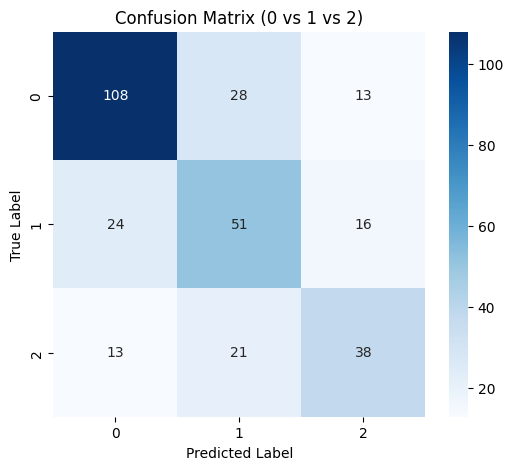

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import time 

# --- 設定 ---
# data変数の定義 (ユーザーのコメントに基づき固定)
data = "1201_humomentstest" 
model = "1201_fourier" 

# === 1, 2. データの読み込みと特徴量定義 ===
merged_data_csv = f"/home/data/{data}/feature_fourier.csv"
try:
    df = pd.read_csv(merged_data_csv)
    print(f"✅ データ読み込み成功: {merged_data_csv}")
except FileNotFoundError:
    print(f"❌ ファイルが見つかりません: {merged_data_csv}")
    exit()

# 現在選択されている特徴量
FEATURE_COLUMNS = [ "f2_norm","f3_norm","f4_norm","f5_norm", "size_count", "R"] 
X = df[FEATURE_COLUMNS]  # 特徴量
y = df["Label"]  # 目的変数

# === 3. 訓練データとテストデータに分割 ===
RANDOM_STATE = 42
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE # 再現性のためrandom_stateを追加
)

# 訓練データとテストデータのクラスごとのカウントを表示
train_counts = y_train_full.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

print("\n--- クラス分布 ---")
print("Train Data Class Distribution:")
print(train_counts)
print("\nTest Data Class Distribution:")
print(test_counts)


# === 4. K-Fold交差検証とハイパーパラメータチューニング ===

print("\n--- 4. K-Fold交差検証とハイパーパラメータチューニング ---")

# class_weight='balanced' を追加して、クラスの不均衡に対応
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=RANDOM_STATE, class_weight='balanced')) 
])

param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1],
    'svm__kernel': ['rbf']
}

start_time = time.time()
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=5, # 5分割を指定
    scoring='f1_macro', # 不均衡データのためF1-macroを使用
    n_jobs=-1 
)

grid_search.fit(X_train_full, y_train_full)
end_time = time.time()

# --- 平均スコアの抽出と表示 ---

# 1. GridSearchCVの結果をDataFrameとして取得
results_df = pd.DataFrame(grid_search.cv_results_)

# 2. 関連する列（パラメータと平均スコア）のみを抽出
mean_scores_df = results_df[[
    'param_svm__C', 
    'param_svm__gamma', 
    'mean_test_score', 
    'std_test_score' # 標準偏差も併せて表示することで信頼度を示す
]].sort_values(by='mean_test_score', ascending=False)

# 3. 平均スコア（F1-macro）を表示
print("\n--- 5分割交差検証 (K-Fold) の全平均スコア ---")
print(f"評価指標: {grid_search.scoring}")
print(f"処理時間: {end_time - start_time:.2f}秒")
print(mean_scores_df.head(10).to_string(index=False)) # 上位10件を表示

# 4. 最適なパラメータとその平均スコアを再確認
best_params_str = ", ".join([f"{k.split('__')[1]}={v}" for k, v in grid_search.best_params_.items()])
print(f"\n🥇 最適なハイパーパラメータ: {best_params_str}")
print(f"🎯 最適なハイパーパラメータでの平均スコア (F1-macro): {grid_search.best_score_:.4f}")

# 5. 最適モデルの取得
best_svm_model = grid_search.best_estimator_

# === 5. 学習済みモデルを保存（最適化されたモデル） ===
model_path = f"svm_model{model}.pkl"
joblib.dump(best_svm_model, model_path)
print(f"\n✅ 最適モデルを保存: {model_path}")

# === 6. 予測と評価 (テストデータで最終評価) ===
y_pred = best_svm_model.predict(X_test)

# レポートを辞書形式で取得
report_dict = classification_report(y_test, y_pred, output_dict=True)

# DataFrameに変換
report_df = pd.DataFrame(report_dict).transpose()

# 表示（必要に応じて四捨五入）
print("\n--- テストデータ評価結果 (Classification Report) ---")
print(report_df.round(4).to_string())

# テストデータと予測結果を結合してCSV保存
test_data_with_results = df.loc[y_test.index].copy()
test_data_with_results['Predicted_Label'] = y_pred

output_path = f"/home/data/{data}/BBBpredicted_results{model}.csv"
test_data_with_results.to_csv(output_path, index=False)
print(f"\n✅ 予測結果をCSVに保存: {output_path}")


# === 7. 混同行列の可視化 ===
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
# ラベルが0, 1, 2であることが多いが、dfのLabelのunique値を使うのが確実
labels = sorted(y_test.unique())
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix ({' vs '.join(map(str, labels))})")
plt.show()